In [1]:
import os
import torch
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

class CustomVOCDataset(torch.utils.data.Dataset):
    def __init__(self, root, image_set='train', transforms=None, label_map=None):
        self.root = root
        self.image_dir = os.path.join(root, "JPEGImages")
        self.annotation_dir = os.path.join(root, "Annotations")
        self.transforms = transforms
        self.label_map = label_map or {
            '0': 1, '1': 2, '2': 3, '3': 4, '4': 5, '5': 6,
            '6': 7, '7': 8, '8': 9, '9': 10,
            '+': 11, '-': 12, '*': 13, '/': 14, '=': 15
        }

        # image_set (train.txtなど) を読み込む
        split_file = os.path.join(root, "ImageSets", "Main", f"{image_set}.txt")
        with open(split_file) as f:
            self.image_ids = [line.strip() for line in f.readlines()]

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.image_dir, f"{image_id}.jpg")
        xml_path = os.path.join(self.annotation_dir, f"{image_id}.xml")

        img = Image.open(img_path).convert("RGB")

        tree = ET.parse(xml_path)
        root = tree.getroot()

        boxes = []
        labels = []

        for obj in root.findall("object"):
            name = obj.find("name").text
            label = self.label_map[name]
            bbox = obj.find("bndbox")
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(label)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64)
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target

Matplotlib is building the font cache; this may take a moment.


In [3]:
# 学習
import csv
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.models.detection._utils import retrieve_out_channels
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.ops import box_iou
from tqdm.auto import tqdm

NUM_CLASSES = 16  # 背景(0) + 数字(10) + 記号(5)
NUM_EPOCHS = 10
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
SCORE_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5
MODEL_PATH = "../outputs/checkpoints/ssd_calculator_state_dict.pth"
CSV_PATH = "../outputs/logs/training_results.csv"

transform = transforms.ToTensor()
train_dataset = CustomVOCDataset(
    root="../data/processed/train",
    image_set="train",
    transforms=transform,
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=lambda batch: tuple(zip(*batch)),
)

# val/ImageSets/Main 内の分割ファイル名は train.txt
val_dataset = CustomVOCDataset(
    root="../data/processed/val",
    image_set="train",
    transforms=transform,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda batch: tuple(zip(*batch)),
)

# COCOで事前学習済みのSSD300-VGG16を使い、分類ヘッドだけ16クラス用に交換する
model = ssd300_vgg16(weights=SSD300_VGG16_Weights.DEFAULT)
model.head.classification_head = SSDClassificationHead(
    retrieve_out_channels(model.backbone, (300, 300)),
    model.anchor_generator.num_anchors_per_location(),
    NUM_CLASSES,
)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

model.to(device)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=0.9,
    weight_decay=5e-4,
)

def evaluate_detector(model, data_loader):
    model.eval()
    true_positive = 0
    false_positive = 0
    false_negative = 0

    with torch.inference_mode():
        for images, targets in tqdm(data_loader, desc="Validation", leave=False):
            predictions = model([image.to(device) for image in images])

            for prediction, target in zip(predictions, targets):
                keep = prediction["scores"].detach().cpu() >= SCORE_THRESHOLD
                pred_boxes = prediction["boxes"].detach().cpu()[keep]
                pred_labels = prediction["labels"].detach().cpu()[keep]
                gt_boxes = target["boxes"].cpu()
                gt_labels = target["labels"].cpu()
                matched_gt = torch.zeros(len(gt_boxes), dtype=torch.bool)

                for pred_box, pred_label in zip(pred_boxes, pred_labels):
                    candidate_indices = torch.where(
                        (gt_labels == pred_label) & (~matched_gt)
                    )[0]
                    if len(candidate_indices) == 0:
                        false_positive += 1
                        continue

                    ious = box_iou(
                        pred_box.unsqueeze(0), gt_boxes[candidate_indices]
                    ).squeeze(0)
                    best_iou, best_position = ious.max(dim=0)
                    if best_iou.item() >= IOU_THRESHOLD:
                        true_positive += 1
                        matched_gt[candidate_indices[best_position]] = True
                    else:
                        false_positive += 1

                false_negative += (~matched_gt).sum().item()

    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return precision, recall, f1

print(
    f"device: {device} / train images: {len(train_dataset)} "
    f"/ val images: {len(val_dataset)}"
)

# 学習開始時にCSVを新規作成し、各エポック終了時に結果を追記する
with open(CSV_PATH, "w", newline="", encoding="utf-8") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["epoch", "train_loss", "precision", "recall", "f1"])

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0

    progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    for images, targets in progress:
        images = [image.to(device) for image in images]
        targets = [
            {key: value.to(device) for key, value in target.items()}
            for target in targets
        ]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress.set_postfix(loss=f"{loss.item():.4f}")

    mean_loss = running_loss / len(train_loader)
    precision, recall, f1 = evaluate_detector(model, val_loader)
    print(
        f"Epoch {epoch + 1}: loss={mean_loss:.4f}, "
        f"precision={precision:.4f}, recall={recall:.4f}, f1={f1:.4f}"
    )

    with open(CSV_PATH, "a", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow([epoch + 1, mean_loss, precision, recall, f1])

torch.save(model.state_dict(), MODEL_PATH)
print(f"学習済みモデルを保存しました: {MODEL_PATH}")
print(f"学習結果を保存しました: {CSV_PATH}")


/Users/uratakato/prog1/play/ai/objectDetection/calculator/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps / train images: 7000 / val images: 1000


Epoch 1/10:   1%|          | 9/875 [00:10<16:52,  1.17s/it, loss=16.0429]


KeyboardInterrupt: 

In [ ]:
# valディレクトリを使った評価（IoU 0.5でのPrecision / Recall / F1）
from torchvision.ops import box_iou

VAL_BATCH_SIZE = 8
SCORE_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5

# val/ImageSets/Main 内の分割ファイル名が train.txt のため image_set="train" を指定
val_dataset = CustomVOCDataset(
    root="../data/processed/val",
    image_set="train",
    transforms=transform,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=lambda batch: tuple(zip(*batch)),
)

model.eval()
true_positive = 0
false_positive = 0
false_negative = 0

with torch.inference_mode():
    for images, targets in tqdm(val_loader, desc="Evaluating"):
        predictions = model([image.to(device) for image in images])

        for prediction, target in zip(predictions, targets):
            scores = prediction["scores"].detach().cpu()
            keep = scores >= SCORE_THRESHOLD
            pred_boxes = prediction["boxes"].detach().cpu()[keep]
            pred_labels = prediction["labels"].detach().cpu()[keep]

            gt_boxes = target["boxes"].cpu()
            gt_labels = target["labels"].cpu()
            matched_gt = torch.zeros(len(gt_boxes), dtype=torch.bool)

            # 予測はscoreの高い順。クラスが一致し、IoUが最大の未対応GTと照合する
            for pred_box, pred_label in zip(pred_boxes, pred_labels):
                candidates = (gt_labels == pred_label) & (~matched_gt)
                candidate_indices = torch.where(candidates)[0]

                if len(candidate_indices) == 0:
                    false_positive += 1
                    continue

                ious = box_iou(
                    pred_box.unsqueeze(0),
                    gt_boxes[candidate_indices],
                ).squeeze(0)
                best_iou, best_position = ious.max(dim=0)

                if best_iou.item() >= IOU_THRESHOLD:
                    true_positive += 1
                    matched_gt[candidate_indices[best_position]] = True
                else:
                    false_positive += 1

            false_negative += (~matched_gt).sum().item()

precision = true_positive / max(true_positive + false_positive, 1)
recall = true_positive / max(true_positive + false_negative, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-12)

print(f"val images : {len(val_dataset)}")
print(f"TP / FP / FN: {true_positive} / {false_positive} / {false_negative}")
print(f"Precision@0.5: {precision:.4f}")
print(f"Recall@0.5   : {recall:.4f}")
print(f"F1@0.5       : {f1:.4f}")


device   : mps
image    : drawing_20250814-105147_cropped.png
equation : 2


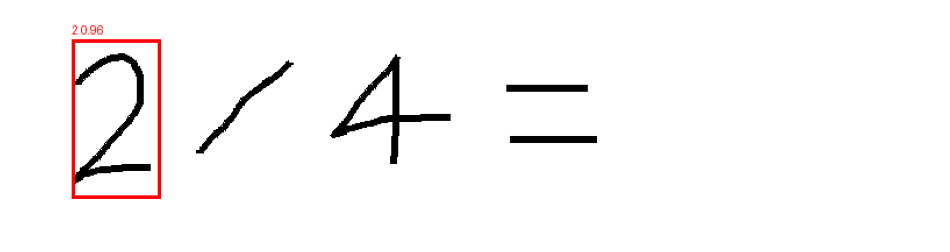

In [4]:
# modelsの学習済みモデルでdata/processed/testの画像を推論する
from pathlib import Path

from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection._utils import retrieve_out_channels
from torchvision.models.detection.ssd import SSDClassificationHead

NUM_CLASSES = 16
SCORE_THRESHOLD = 0.5
LABEL_MAP = {
    1: '0', 2: '1', 3: '2', 4: '3', 5: '4',
    6: '5', 7: '6', 8: '7', 9: '8', 10: '9',
    11: '+', 12: '-', 13: '*', 14: '/', 15: '=',
}

# Notebookをプロジェクト直下・notebooks内のどちらから開いても動くようにする
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'models').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_PATH = PROJECT_ROOT / 'models' / 'ssd_calculator_state_dict.pth'
TEST_DIR = PROJECT_ROOT / 'data' / 'processed' / 'test'

if torch.cuda.is_available():
    inference_device = torch.device('cuda')
elif torch.backends.mps.is_available():
    inference_device = torch.device('mps')
else:
    inference_device = torch.device('cpu')

# state_dictと同じ16クラス構成を作り、保存済みの重みを読み込む
inference_model = ssd300_vgg16(weights=None, weights_backbone=None)
inference_model.head.classification_head = SSDClassificationHead(
    retrieve_out_channels(inference_model.backbone, (300, 300)),
    inference_model.anchor_generator.num_anchors_per_location(),
    NUM_CLASSES,
)
state_dict = torch.load(MODEL_PATH, map_location=inference_device, weights_only=True)
inference_model.load_state_dict(state_dict)
inference_model.to(inference_device).eval()

# Noneならtest内の先頭画像を使用。ファイル名を指定して切り替えられる
TEST_IMAGE_NAME = None  # 例: 'drawing_20250814-074124_cropped.png'
image_paths = sorted(
    path for path in TEST_DIR.iterdir()
    if path.suffix.lower() in {'.jpg', '.jpeg', '.png'}
)
if not image_paths:
    raise FileNotFoundError(f'テスト画像がありません: {TEST_DIR}')
image_path = TEST_DIR / TEST_IMAGE_NAME if TEST_IMAGE_NAME else image_paths[3]
if not image_path.exists():
    raise FileNotFoundError(f'画像がありません: {image_path}')

original_image = Image.open(image_path).convert('RGB')
input_tensor = transforms.ToTensor()(original_image).to(inference_device)
with torch.inference_mode():
    prediction = inference_model([input_tensor])[0]

keep = prediction['scores'].detach().cpu() >= SCORE_THRESHOLD
boxes = prediction['boxes'].detach().cpu()[keep]
labels = prediction['labels'].detach().cpu()[keep]
scores = prediction['scores'].detach().cpu()[keep]

# 左から順番に並べて、推論した数式として表示する
detections = sorted(
    zip(boxes, labels, scores),
    key=lambda item: item[0][0].item(),
)
equation = ''.join(LABEL_MAP[int(label)] for _, label, _ in detections)

drawn_image = original_image.copy()
draw = ImageDraw.Draw(drawn_image)
for box, label, score in detections:
    x1, y1, x2, y2 = box.tolist()
    label_text = f'{LABEL_MAP[int(label)]} {score.item():.2f}'
    draw.rectangle((x1, y1, x2, y2), outline='red', width=3)
    draw.text((x1, max(0, y1 - 15)), label_text, fill='red')

print(f'device   : {inference_device}')
print(f'image    : {image_path.name}')
print(f'equation : {equation or "検出なし"}')
plt.figure(figsize=(12, 4))
plt.imshow(drawn_image)
plt.axis('off')
plt.show()
